In [1]:



# -------------------------------
# YouTube Data Cleaning Script
# -------------------------------

import pandas as pd
import numpy as np

# 1️⃣ Charger le fichier CSV
try:
    df = pd.read_csv("/Users/amrani/Downloads/Global YouTube Statistics.csv", encoding='latin1')
    print("✅ Dataset loaded successfully!")
except FileNotFoundError:
    print("❌ File not found. Check the path.")
except UnicodeDecodeError:
    print("❌ Encoding error. Try another encoding (latin1, cp1252, utf-8).")

# 2️⃣ Aperçu des données
print("\n--- Dataset Head ---")
print(df.head())
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3️⃣ Supprimer les doublons
df = df.drop_duplicates()
print("\n✅ Duplicates removed.")

# 4️⃣ Gestion des valeurs manquantes
# Exemple pour colonnes importantes
# Remplacer les valeurs manquantes numériques par la moyenne
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Remplacer les valeurs manquantes textuelles par "Unknown"
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col].fillna("Unknown", inplace=True)

print("✅ Missing values handled.")

# 5️⃣ Correction des formats incohérents
# Exemple : convertir les colonnes de dates si elles existent
# df['join_date'] = pd.to_datetime(df['join_date'], errors='coerce')

# 6️⃣ Détection et gestion des outliers (exemple simple)
# Ici on utilise l'IQR pour les colonnes numériques
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Limiter les outliers aux bornes
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("✅ Outliers handled.")

# 7️⃣ Vérification finale
print("\n--- Cleaned Dataset Info ---")
print(df.info())

# 8️⃣ Sauvegarder le dataset nettoyé
df.to_csv("/Users/amrani/Downloads/Global YouTube Statistics_cleaned.csv", index=False)
print("\n✅ Cleaned dataset saved as 'Global YouTube Statistics_cleaned.csv'")


✅ Dataset loaded successfully!

--- Dataset Head ---
   rank                    Youtuber  subscribers   video views  \
0     1                    T-Series    245000000  2.280000e+11   
1     2              YouTube Movies    170000000  0.000000e+00   
2     3                     MrBeast    166000000  2.836884e+10   
3     4  Cocomelon - Nursery Rhymes    162000000  1.640000e+11   
4     5                   SET India    159000000  1.480000e+11   

           category                       Title  uploads        Country  \
0             Music                    T-Series    20082          India   
1  Film & Animation               youtubemovies        1  United States   
2     Entertainment                     MrBeast      741  United States   
3         Education  Cocomelon - Nursery Rhymes      966  United States   
4             Shows                   SET India   116536          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  

/var/folders/r4/qbvwglqj0_gg_d5kr_vqrftc0000gn/T/ipykernel_4541/1571377680.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/var/folders/r4/qbvwglqj0_gg_d5kr_vqrftc0000gn/T/ipykernel_4541/1571377680.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [2]:
df

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1.0,T-Series,39750000.0,2.745454e+10,Music,T-Series,6377.0,India,IN,Music,...,722697.830547,2006.0,Mar,13.0,28.1,8.869471e+08,5.36,471031528.0,20.593684,78.962880
1,2.0,YouTube Movies,39750000.0,0.000000e+00,Film & Animation,youtubemovies,1.0,United States,US,Games,...,349079.132219,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3.0,MrBeast,39750000.0,2.745454e+10,Entertainment,MrBeast,741.0,United States,US,Entertainment,...,722697.830547,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4.0,Cocomelon - Nursery Rhymes,39750000.0,2.745454e+10,Education,Cocomelon - Nursery Rhymes,966.0,United States,US,Education,...,722697.830547,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5.0,SET India,39750000.0,2.745454e+10,Shows,SET India,6377.0,India,IN,Entertainment,...,722697.830547,2006.0,Sep,20.0,28.1,8.869471e+08,5.36,471031528.0,20.593684,78.962880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991.0,Natan por Aï¿,12300000.0,9.029610e+09,Sports,Natan por Aï¿,1200.0,Brazil,BR,Entertainment,...,700000.000000,2017.0,Feb,12.0,51.3,2.125594e+08,12.08,183241641.0,-4.151150,-51.925280
991,992.0,Free Fire India Official,12300000.0,1.674410e+09,People & Blogs,Free Fire India Official,1500.0,India,IN,Games,...,300000.000000,2018.0,Sep,14.0,28.1,8.869471e+08,5.36,471031528.0,20.593684,78.962880
992,993.0,Panda,12300000.0,2.214684e+09,Unknown,HybridPanda,2452.0,United Kingdom,GB,Games,...,1000.000000,2006.0,Sep,11.0,60.0,6.683440e+07,3.85,55908316.0,55.378051,-3.435973
993,994.0,RobTopGames,12300000.0,3.741235e+08,Gaming,RobTopGames,39.0,Sweden,SE,Games,...,100000.000000,2012.0,May,9.0,67.0,1.028545e+07,6.48,9021165.0,60.128161,18.643501


In [4]:
# -------------------------------
# YouTube EDA Script
# -------------------------------

import seaborn as sns
import matplotlib.pyplot as plt



# 2️⃣ Aperçu rapide
print("✅ Dataset Head:")
print(df.head())

print("\n✅ Dataset Info:")
print(df.info())

print("\n✅ Statistical Summary:")
print(df.describe())



✅ Dataset Head:
   rank                    Youtuber  subscribers   video views  \
0   1.0                    T-Series   39750000.0  2.745454e+10   
1   2.0              YouTube Movies   39750000.0  0.000000e+00   
2   3.0                     MrBeast   39750000.0  2.745454e+10   
3   4.0  Cocomelon - Nursery Rhymes   39750000.0  2.745454e+10   
4   5.0                   SET India   39750000.0  2.745454e+10   

           category                       Title  uploads        Country  \
0             Music                    T-Series   6377.0          India   
1  Film & Animation               youtubemovies      1.0  United States   
2     Entertainment                     MrBeast    741.0  United States   
3         Education  Cocomelon - Nursery Rhymes    966.0  United States   
4             Shows                   SET India   6377.0          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  ...                 722697.830547   


Colonnes disponibles : Index(['rank', 'youtuber', 'subscribers', 'video views', 'category', 'title',
       'uploads', 'country', 'abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'gross tertiary education enrollment (%)', 'population',
       'unemployment rate', 'urban_population', 'latitude', 'longitude'],
      dtype='object')


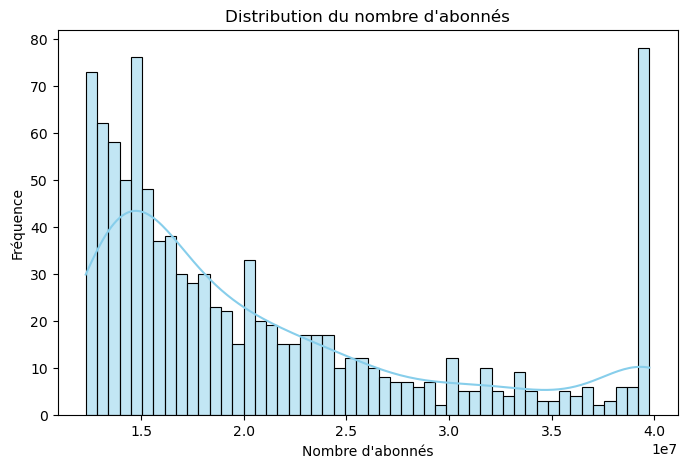

Colonne 'views' introuvable.


In [6]:
# -------------------------------
# 3️⃣ Analyse univariée
# -------------------------------


# 🔹 Normalisation des noms de colonnes : minuscules et suppression des espaces
df.rename(columns=lambda x: x.strip().lower(), inplace=True)

# Vérifie les colonnes disponibles
print("Colonnes disponibles :", df.columns)

# Histogramme du nombre d'abonnés
if 'subscribers' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['subscribers'], bins=50, kde=True, color='skyblue')
    plt.title("Distribution du nombre d'abonnés")
    plt.xlabel("Nombre d'abonnés")
    plt.ylabel("Fréquence")
    plt.show()
else:
    print("Colonne 'subscribers' introuvable.")

# Boxplot des vues totales
if 'views' in df.columns:
    # Conversion en numérique si nécessaire
    df['views'] = pd.to_numeric(df['views'], errors='coerce')
    
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df['views'], color='lightgreen')
    plt.title("Boxplot des vues totales")
    plt.xlabel("Vues")
    plt.show()
else:
    print("Colonne 'views' introuvable.")




❌ Les colonnes suivantes sont manquantes et le scatter plot ne peut pas être tracé : ['estimated_revenue']


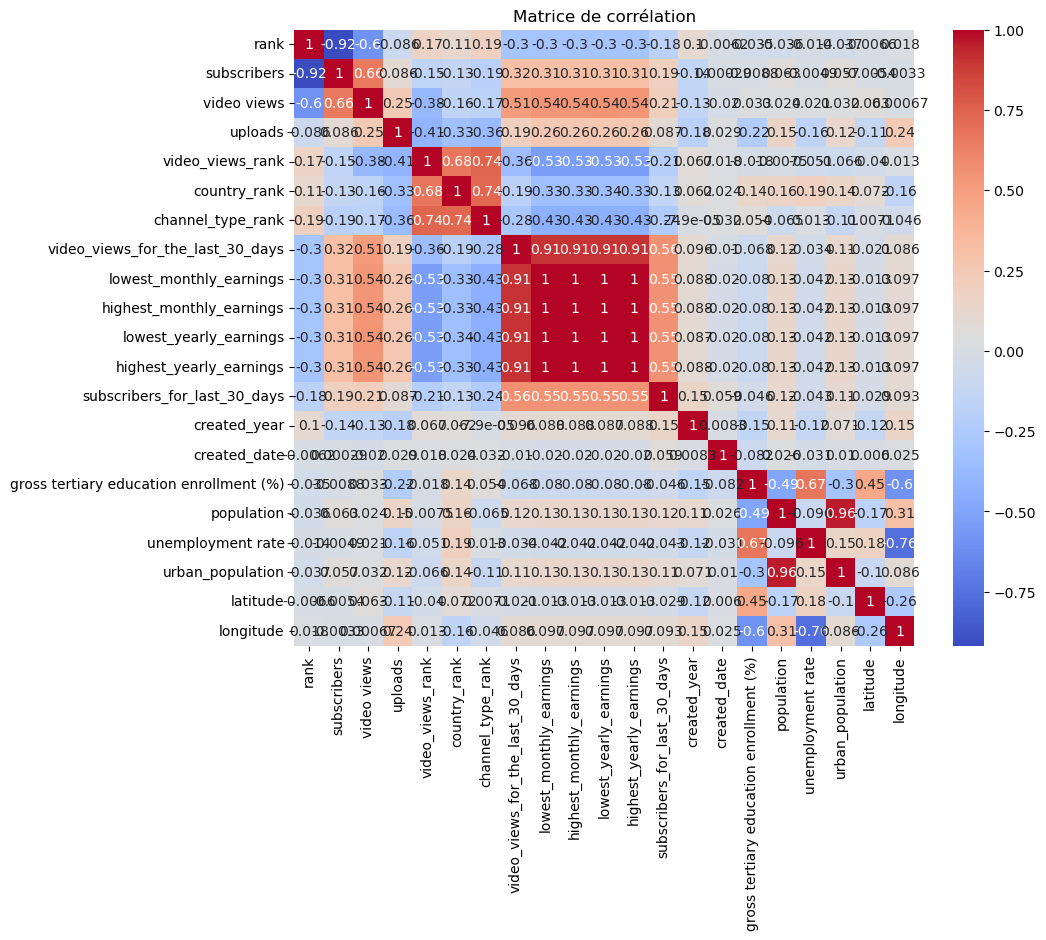

In [8]:

# Scatter plot : abonnés vs revenus estimés
# -------------------------------

# Vérifier que les colonnes existent
required_cols = ['subscribers', 'estimated_revenue', 'category']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"❌ Les colonnes suivantes sont manquantes et le scatter plot ne peut pas être tracé : {missing_cols}")
else:
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        x='subscribers',
        y='estimated_revenue',
        data=df,
        hue='category',
        palette='tab10'
    )
    plt.title("Abonnés vs Revenus estimés")
    plt.xlabel("Abonnés")
    plt.ylabel("Revenus estimés")
    plt.legend(title='Catégorie')
    plt.show()

# -------------------------------
# Matrice de corrélation
# -------------------------------

num_cols = df.select_dtypes(include='number').columns
if len(num_cols) < 2:
    print("❌ Pas assez de colonnes numériques pour calculer la corrélation.")
else:
    plt.figure(figsize=(10,8))
    corr = df[num_cols].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title("Matrice de corrélation")
    plt.show()




In [13]:
# 5️⃣ Analyse multivariée
# -------------------------------

# Colonnes à utiliser pour le pairplot
columns_to_plot = ['subscribers', 'views', 'estimated_revenue', 'total_videos']
# Garder seulement les colonnes existantes dans le dataset
available_cols = [col for col in columns_to_plot if col in df.columns]

if len(available_cols) < 2:
    print("❌ Pas assez de colonnes disponibles pour le pairplot :", available_cols)
else:
    sns.pairplot(df[available_cols])
    plt.show()

# -------------------------------
# 6️⃣ Détection des anomalies simples
# -------------------------------

# Vérifier que les colonnes nécessaires existent
required_cols = ['channel_name', 'subscribers', 'estimated_revenue']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"❌ Impossible de détecter les top chaînes, colonnes manquantes : {missing_cols}")
else:
    # Chaînes du top 1% par abonnés
    top_channels = df[df['subscribers'] > df['subscribers'].quantile(0.99)]
    print("\n✅ Top 1% chaînes par abonnés :")
    print(top_channels[required_cols])

❌ Pas assez de colonnes disponibles pour le pairplot : ['subscribers']
❌ Impossible de détecter les top chaînes, colonnes manquantes : ['channel_name', 'estimated_revenue']


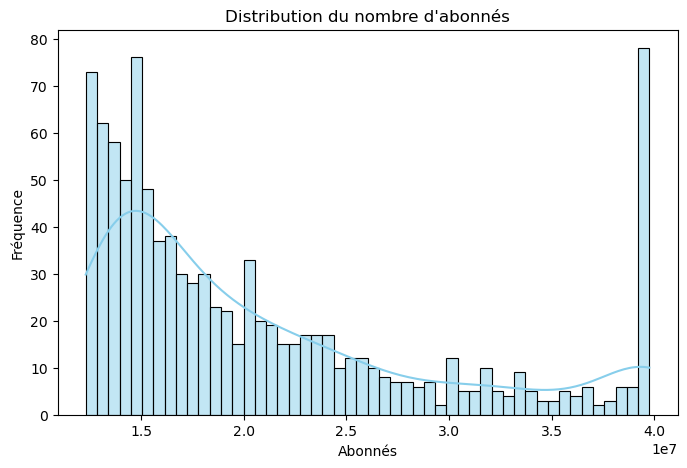

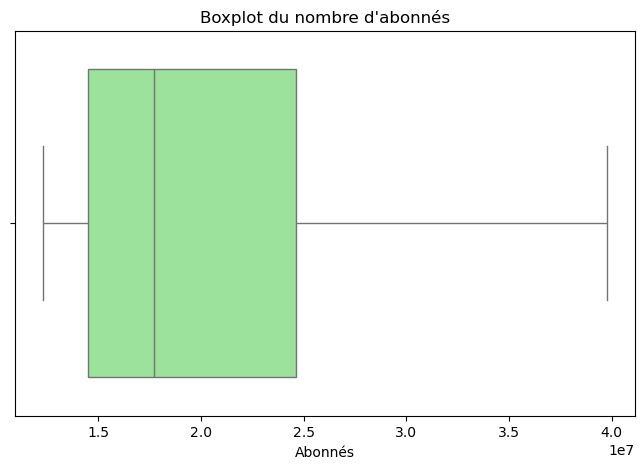

❌ Colonne 'estimated_revenue' ou 'category' manquante pour cette visualisation.


In [15]:
# -------------------------------
# YouTube Visualisation & Storytelling
# -------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger le dataset nettoyé
df = pd.read_csv("/Users/amrani/Downloads/Global YouTube Statistics_cleaned.csv")

# Nettoyage rapide des colonnes pour éviter les erreurs
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# -------------------------------
# 1️⃣ Distribution des abonnés
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['subscribers'], bins=50, kde=True, color='skyblue')
plt.title("Distribution du nombre d'abonnés")
plt.xlabel("Abonnés")
plt.ylabel("Fréquence")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df['subscribers'], color='lightgreen')
plt.title("Boxplot du nombre d'abonnés")
plt.xlabel("Abonnés")
plt.show()

# Revenus estimés par catégorie
if 'estimated_revenue' in df.columns and 'category' in df.columns:
    plt.figure(figsize=(12,6))
    sns.barplot(
        x='category',
        y='estimated_revenue',
        data=df,
        ci=None,
        palette='tab20'
    )
    plt.xticks(rotation=45)
    plt.title("Revenus estimés par catégorie")
    plt.ylabel("Revenus estimés")
    plt.xlabel("Catégorie")
    plt.show()
    
    plt.figure(figsize=(12,6))
    sns.violinplot(
        x='category',
        y='estimated_revenue',
        data=df,
        palette='tab20'
    )
    plt.xticks(rotation=45)
    plt.title("Distribution des revenus estimés par catégorie")
    plt.ylabel("Revenus estimés")
    plt.xlabel("Catégorie")
    plt.show()
else:
    print("❌ Colonne 'estimated_revenue' ou 'category' manquante pour cette visualisation.")

In [17]:
# -------------------------------
# Modélisation simple (Régression Linéaire)
# -------------------------------

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Charger le dataset nettoyé
df = pd.read_csv("/Users/amrani/Downloads/Global YouTube Statistics_cleaned.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# -------------------------------
# 1️⃣ Définir les features et la target
# -------------------------------
# Exemple : prédire les abonnés à partir des vues et du nombre de vidéos
features = [col for col in ['views', 'total_videos'] if col in df.columns]
target = 'subscribers'

if target not in df.columns or len(features) < 1:
    print("❌ Colonnes nécessaires manquantes pour la régression.")
else:
    X = df[features]
    y = df[target]

    # -------------------------------
    # 2️⃣ Split train/test
    # -------------------------------
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # -------------------------------
    # 3️⃣ Entraîner le modèle
    # -------------------------------
    model = LinearRegression()
    model.fit(X_train, y_train)

    # -------------------------------
    # 4️⃣ Prédictions
    # -------------------------------
    y_pred = model.predict(X_test)

    # -------------------------------
    # 5️⃣ Évaluation
    # -------------------------------
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    print(f"\n✅ RMSE : {rmse:.2f}")
    print(f"✅ R² : {r2:.2f}")

    # -------------------------------
    # 6️⃣ Visualisation prédictions vs réel
    # -------------------------------
    plt.figure(figsize=(8,5))
    plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Valeurs réelles")
    plt.ylabel("Prédictions")
    plt.title("Prédictions vs Valeurs réelles (Régression linéaire)")
    plt.show()


❌ Colonnes nécessaires manquantes pour la régression.


In [21]:
# -------------------------------
# Interpretation & Recommendations
# -------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger le dataset nettoyé
df = pd.read_csv("/Users/amrani/Downloads/Global YouTube Statistics_cleaned.csv")

# Nettoyer les noms de colonnes : minuscules et underscores
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# -------------------------------
# 1️⃣ Identifier les facteurs clés qui influencent les abonnés et revenus
# -------------------------------
numeric_cols = df.select_dtypes(include='number').columns.tolist()
target_cols = ['subscribers', 'estimated_revenue']

for target in target_cols:
    if target in df.columns:
        corr = df[numeric_cols].corr()[target].sort_values(ascending=False)
        print(f"\n✅ Top correlations with {target}:")
        print("Top facteurs positifs :")
        print(corr.head(5))
        print("Top facteurs négatifs :")
        print(corr.tail(5))

# -------------------------------
# 2️⃣ Visualiser les insights principaux
# -------------------------------
if 'category' in df.columns and 'estimated_revenue' in df.columns:
    plt.figure(figsize=(12,6))
    avg_revenue = df.groupby('category')['estimated_revenue'].mean().sort_values(ascending=False)
    sns.barplot(x=avg_revenue.index, y=avg_revenue.values, palette='tab20')
    plt.xticks(rotation=45)
    plt.ylabel("Revenus moyens estimés")
    plt.xlabel("Catégorie")
    plt.title("Revenus moyens par catégorie de chaîne")
    plt.show()

# -------------------------------
# 3️⃣ Recommandations simples basées sur les données
# -------------------------------
if 'subscribers' in df.columns:
    # Top 5% des chaînes par abonnés
    top_channels = df[df['subscribers'] > df['subscribers'].quantile(0.95)]
    print("\n🎯 Recommandation : Observer les pratiques des chaînes du top 5% pour booster la croissance")

    if 'total_videos' in df.columns:
        print("💡 Astuce : Augmenter la fréquence de publication peut aider à gagner plus d'abonnés")
        
    if 'category' in df.columns:
        print("💡 Astuce : Choisir des catégories performantes peut augmenter le revenu estimé")



✅ Top correlations with subscribers:
Top facteurs positifs :
subscribers                         1.000000
video_views                         0.658717
video_views_for_the_last_30_days    0.316538
lowest_yearly_earnings              0.314010
highest_yearly_earnings             0.313442
Name: subscribers, dtype: float64
Top facteurs négatifs :
country_rank        -0.128122
created_year        -0.136406
video_views_rank    -0.148327
channel_type_rank   -0.187227
rank                -0.918083
Name: subscribers, dtype: float64

🎯 Recommandation : Observer les pratiques des chaînes du top 5% pour booster la croissance
💡 Astuce : Choisir des catégories performantes peut augmenter le revenu estimé
